# **Ridge Regression**

In [ ]:
#importing library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score as r2_score_func
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline


In [ ]:
#loading teh dataset
df = pd.read_csv("/content/random_stock_market_dataset.csv")

In [ ]:
#describing the dataset
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    60 non-null     object 
 1   Open    60 non-null     float64
 2   High    60 non-null     float64
 3   Low     60 non-null     float64
 4   Close   60 non-null     float64
 5   Volume  60 non-null     int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 2.9+ KB


In [ ]:
df.describe()

,Open,High,Low,Close,Volume
count,60.000000,60.000000,60.000000,60.000000,60.000000
mean,310.552000,322.589833,308.056833,320.412667,95405.516667
std,108.859051,109.095813,108.986426,109.157159,54895.342146
min,112.680000,123.780000,109.430000,121.270000,13193.000000
25%,222.957500,238.247500,220.042500,237.242500,48016.500000
50%,303.240000,313.800000,302.385000,309.385000,93850.500000
75%,396.150000,415.915000,392.905000,413.462500,130917.250000
max,492.790000,501.670000,492.300000,500.420000,195189.000000


In [ ]:
df.head()

,Date,Open,High,Low,Close,Volume
0,2024-01-01,296.45,307.31,293.96,303.72,93133
1,2024-01-02,190.11,193.10,187.21,191.40,64993
2,2024-01-03,197.41,208.64,193.37,205.89,70326
3,2024-01-04,253.13,262.67,248.67,258.95,17358
4,2024-01-05,241.35,253.09,238.99,252.20,20847


In [ ]:
df.tail()

,Date,Open,High,Low,Close,Volume
55,2024-02-25,170.55,181.13,167.39,178.58,47071
56,2024-02-26,187.88,195.26,186.36,193.36,115659
57,2024-02-27,355.67,375.14,353.60,370.56,62294
58,2024-02-28,289.90,298.27,289.06,298.01,108022
59,2024-02-29,120.34,131.84,116.30,129.95,64201


In [ ]:
df = df.drop("Date", axis=1)

In [ ]:
# Features and target
X = df[["Open", "High", "Low", "Volume"]]
y = df["Close"]

In [ ]:
#scale feature
scaler = StandardScaler()
X = scaler.fit_transform(X)

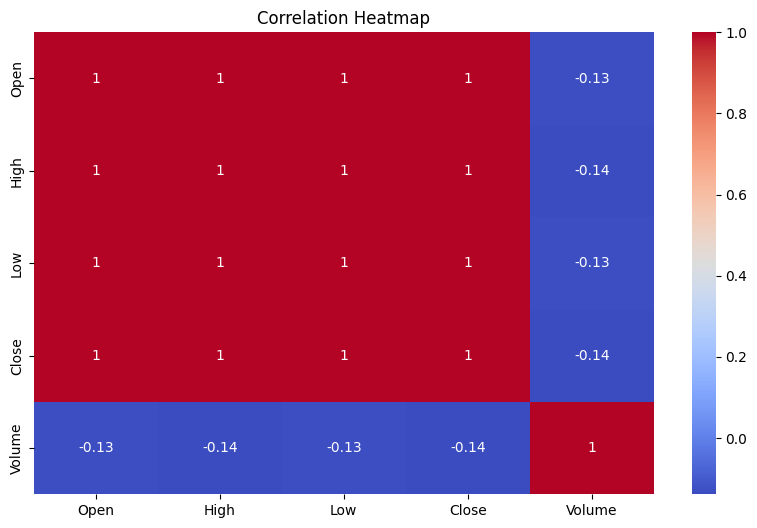

In [ ]:
#concept diagram
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


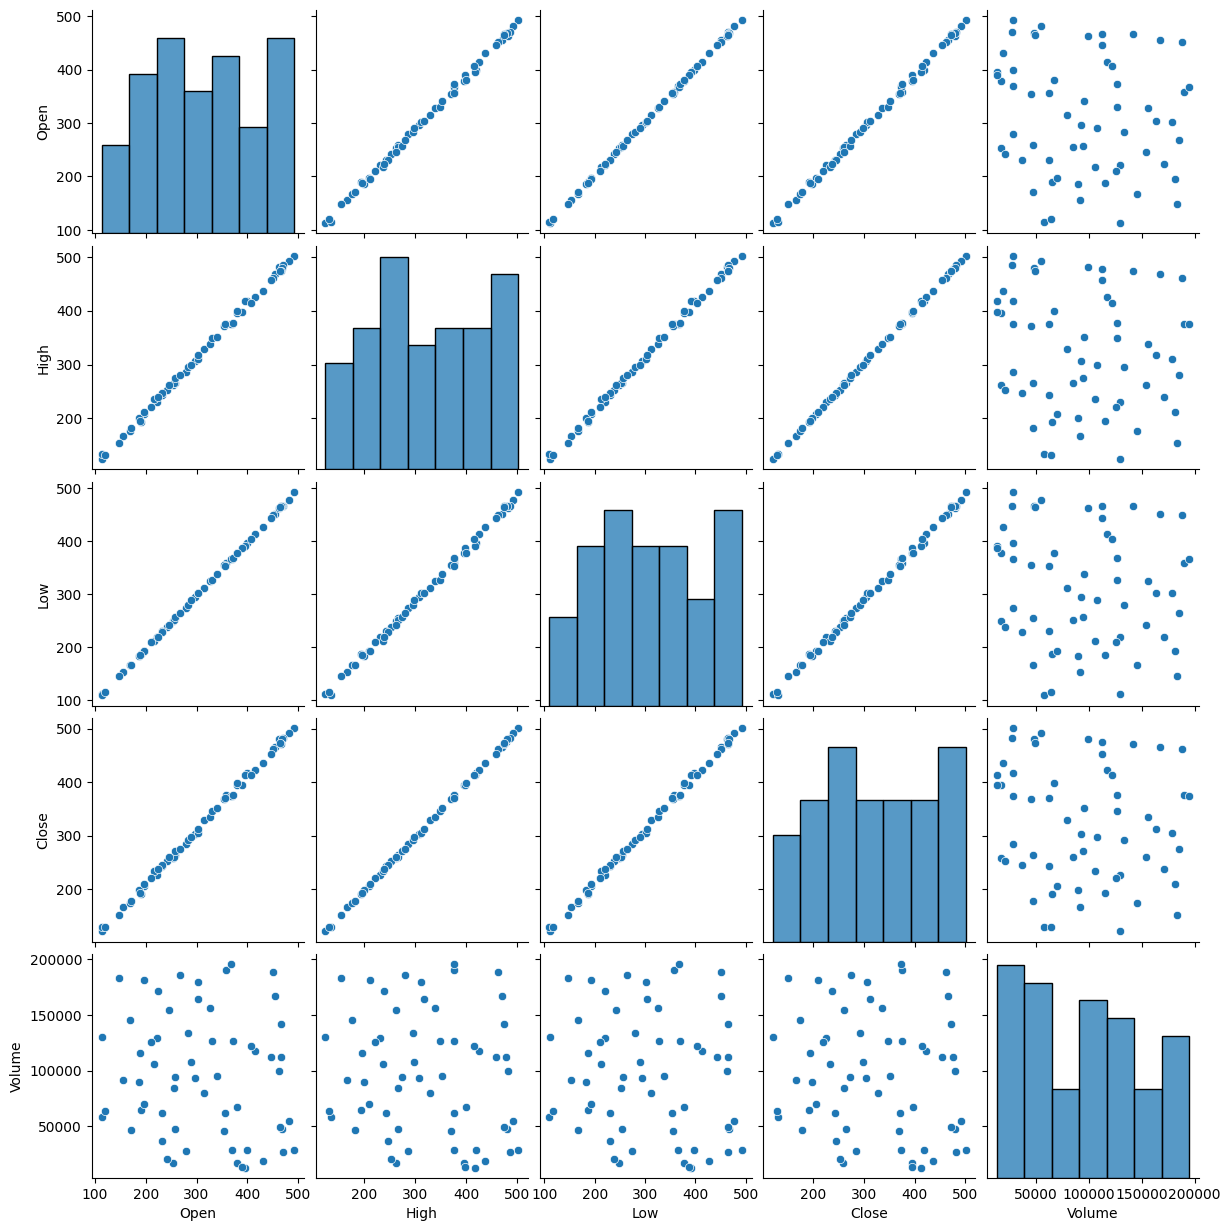

In [ ]:
#scatter plot comparing all parmeter in multiple scatter plot
sns.pairplot(df)
plt.show()


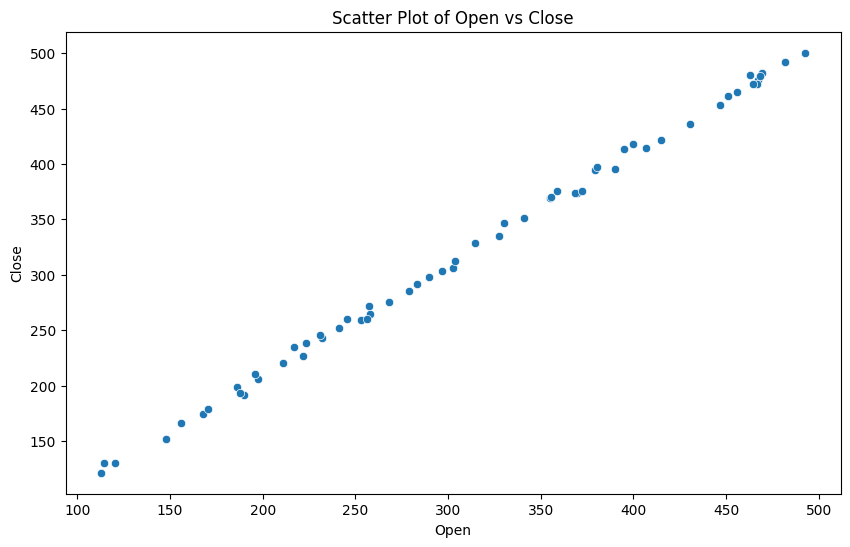

In [ ]:
#plotting part scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Open", y="Close", data=df)
plt.title("Scatter Plot of Open vs Close")
plt.xlabel("Open")
plt.ylabel("Close")
plt.show()

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#ridge model
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)


Ridge()

In [ ]:
y_pred = ridge.predict(X_test)

In [ ]:
#MSE , RMSE, R2_score
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
rmse = root_mean_squared_error(y_test, y_pred)
print("Root Mean Squared Error:", rmse)
r2_score_value = r2_score_func(y_test, y_pred)
print("R-squared Score:", r2_score_value)


Mean Squared Error: 4.574652548948979
Root Mean Squared Error: 2.138843741124858
R-squared Score: 0.9995600847511701


In [ ]:
#intercept and coefficients
print("Coefficients:", ridge.coef_)
print("Intercept:", ridge.intercept_)
#printing the equation
print("ridge equation :", "y = ", ridge.intercept_, " + ", " + ".join([f"{ridge.coef_[i]} * {df.columns[i]}" for i in range(len(ridge.coef_))]))

Coefficients: [34.14167374 39.4277235  33.99801266 -0.62114851]
Intercept: 320.4871464511673
ridge equation : y =  320.4871464511673  +  34.14167373930064 * Open + 39.427723500566636 * High + 33.99801265651617 * Low + -0.6211485121524498 * Close


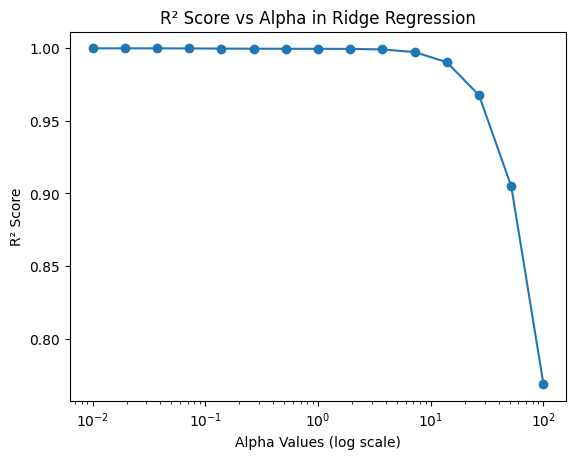

In [ ]:
# Train model for each alpha
alphas = np.logspace(-2, 2, 15)
r2_scores = []
for a in alphas:
    model = Ridge(alpha=a)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2_scores.append(r2_score_func(y_test, y_pred))

#Plot
plt.figure()
plt.plot(alphas, r2_scores, marker='o')
plt.xscale('log')
plt.xlabel("Alpha Values (log scale)")
plt.ylabel("R² Score")
plt.title("R² Score vs Alpha in Ridge Regression")
plt.show()

In [ ]:
#Alpha Range
alphas = np.logspace(-2, 2, 15)

train_r2_scores = []
test_r2_scores = []

# Train model for each alpha
for a in alphas:
    model = Ridge(alpha=a)
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_r2_scores.append(r2_score_func(y_train, train_pred))
    test_r2_scores.append(r2_score_func(y_test, test_pred))

# Create Results Table
multi_alpha_results_table = pd.DataFrame({
    "Alpha (Penalty)": alphas,
    "Train R² Score": train_r2_scores,
    "Test R² Score": test_r2_scores
})

# Format values for better readability
multi_alpha_results_table["Alpha (Penalty)"] = multi_alpha_results_table["Alpha (Penalty)"].round(4)
multi_alpha_results_table["Train R² Score"] = multi_alpha_results_table["Train R² Score"].round(4)
multi_alpha_results_table["Test R² Score"] = multi_alpha_results_table["Test R² Score"].round(4)

print(multi_alpha_results_table)


    Alpha (Penalty)  Train R² Score  Test R² Score
0            0.0100          0.9998         0.9999
1            0.0193          0.9998         0.9999
2            0.0373          0.9997         0.9999
3            0.0720          0.9996         0.9998
4            0.1389          0.9994         0.9997
5            0.2683          0.9993         0.9996
6            0.5179          0.9992         0.9996
7            1.0000          0.9991         0.9996
8            1.9307          0.9990         0.9995
9            3.7276          0.9984         0.9991
10           7.1969          0.9967         0.9973
11          13.8950          0.9908         0.9903
12          26.8270          0.9728         0.9675
13          51.7947          0.9250         0.9049
14         100.0000          0.8234         0.7686


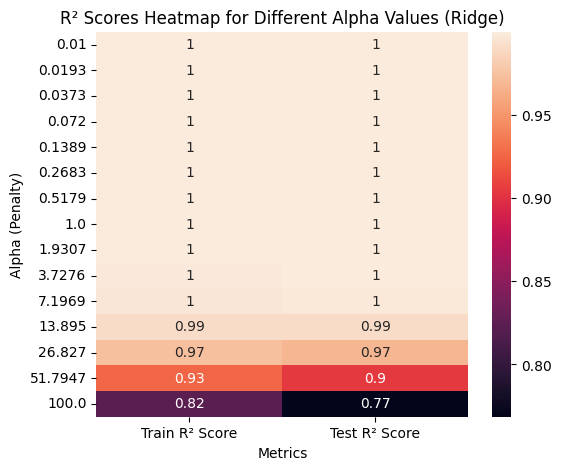

In [ ]:
#plotting heatmap for these alpha values
heatmap_data = multi_alpha_results_table.set_index("Alpha (Penalty)")

plt.figure(figsize=(6,5))
sns.heatmap(heatmap_data, annot=True)
plt.title("R² Scores Heatmap for Different Alpha Values (Ridge)")
plt.xlabel("Metrics")
plt.ylabel("Alpha (Penalty)")
plt.show()

In [ ]:
#using ridgecv
ridge_cv = RidgeCV(alphas=alphas, scoring='r2', cv=5)
ridge_cv.fit(X_train, y_train)
best_alpha = ridge_cv.alpha_
print("Best Alpha:", best_alpha)



Best Alpha: 0.01


In [ ]:
#Alpha Range
alphas = np.logspace(-2, 2, 20)   # 0.01 to 100

ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring='r2')
ridge_cv.fit(X_train, y_train)


# best alpha
best_alpha = ridge_cv.alpha_
# predicting
train_pred = ridge_cv.predict(X_train)
test_pred = ridge_cv.predict(X_test)

train_r2 = r2_score_func(y_train, train_pred)
test_r2 = r2_score_func(y_test, test_pred)

#result table
results_table = pd.DataFrame({
    "Best Alpha (Penalty)": [best_alpha],
    "Train R² Score": [train_r2],
    "Test R² Score": [test_r2]
}).round(4)
print(results_table)

   Best Alpha (Penalty)  Train R² Score  Test R² Score
0                  0.01          0.9998         0.9999


In [ ]:
#making pipeline
model = make_pipeline(
    PolynomialFeatures(degree=2),
    Ridge(alpha=best_alpha)
)

model.fit(X_train, y_train)

train_r2 = model.score(X_train, y_train)
test_r2 = model.score(X_test, y_test)

print("Train R²:", train_r2)
print("Test R²:", test_r2)




Train R²: 0.9998239469696611
Test R²: 0.9998053166932649
